In [15]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

In [16]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Path to dataset files: /kaggle/input/plantvillage-dataset


In [17]:
import os


In [18]:
def list_directories(path):
    """Lists all directories in the given path."""
    directories = []
    for item in os.listdir(path):
        item_path = os.path.join(path, item)
        if os.path.isdir(item_path):
            directories.append(item)
    return directories
path = "/kaggle/input/plantvillage-dataset/plantvillage dataset/color"

In [19]:
# Example usage:
print(f"Directories in '{path}':")
dirs_in_color_path = list_directories(path)
for d in dirs_in_color_path:
    print(d)

Directories in '/kaggle/input/plantvillage-dataset/plantvillage dataset/color':
Tomato___Late_blight
Tomato___healthy
Grape___healthy
Orange___Haunglongbing_(Citrus_greening)
Soybean___healthy
Squash___Powdery_mildew
Potato___healthy
Corn_(maize)___Northern_Leaf_Blight
Tomato___Early_blight
Tomato___Septoria_leaf_spot
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Strawberry___Leaf_scorch
Peach___healthy
Apple___Apple_scab
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Tomato___Bacterial_spot
Apple___Black_rot
Blueberry___healthy
Cherry_(including_sour)___Powdery_mildew
Peach___Bacterial_spot
Apple___Cedar_apple_rust
Tomato___Target_Spot
Pepper,_bell___healthy
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
Potato___Late_blight
Tomato___Tomato_mosaic_virus
Strawberry___healthy
Apple___healthy
Grape___Black_rot
Potato___Early_blight
Cherry_(including_sour)___healthy
Corn_(maize)___Common_rust_
Grape___Esca_(Black_Measles)
Raspberry___healthy
Tomato___Leaf_Mold
Tomato___Spider_mites Two-spotted_s

In [20]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    path,
    batch_size=8,
    image_size=(224, 224),
    seed=42,
    subset="training",
    validation_split=0.25
)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    path,
    batch_size=8,
    image_size=(224, 224),
    seed=42,
    subset="validation",
    validation_split=0.25
)
total = tf.data.experimental.cardinality(train_dataset).numpy()
train_size  = int(0.75 * total)

Found 54305 files belonging to 38 classes.
Using 40729 files for training.
Found 54305 files belonging to 38 classes.
Using 13576 files for validation.


In [21]:
class_names = train_dataset.class_names
print(class_names)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

In [22]:
# train_dataset = train_dataset.map(lambda x, y: (x / 255.0, y))
# test_dataset = test_dataset.map(lambda x, y: (x / 255.0, y))

In [23]:
for image, label in train_dataset.take(1):
    print("Image shape: ", image[0].shape)
    print("Label: ", label[0])


Image shape:  (224, 224, 3)
Label:  tf.Tensor(24, shape=(), dtype=int32)


In [24]:
y = np.concatenate([y for x, y in train_dataset], axis=0)
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y), y=y)
class_weights_dict = dict(enumerate(class_weights))

In [25]:
print(class_weights_dict)

{0: np.float64(2.261214745725072), 1: np.float64(2.3712738705170007), 2: np.float64(5.103884711779449), 3: np.float64(0.8699803485987696), 4: np.float64(0.9451638355147127), 5: np.float64(1.3883624215980366), 6: np.float64(1.6565931831123404), 7: np.float64(2.8735007760688585), 8: np.float64(1.184326839197441), 9: np.float64(1.430995713583023), 10: np.float64(1.2277385904624103), 11: np.float64(1.268421052631579), 12: np.float64(1.0256610425585495), 13: np.float64(1.3347643704529069), 14: np.float64(3.413426081126383), 15: np.float64(0.25851803894686065), 16: np.float64(0.6304798761609907), 17: np.float64(4.106573906029442), 18: np.float64(1.4702548552451087), 19: np.float64(0.9612697663441114), 20: np.float64(1.4386789120452137), 21: np.float64(1.4290877192982456), 22: np.float64(9.160818713450292), 23: np.float64(3.8693710811324338), 24: np.float64(0.2787557319827527), 25: np.float64(0.7800697157741515), 26: np.float64(1.2944635138571066), 27: np.float64(3.1067124332570555), 28: np.f

In [26]:
for images, labels in train_dataset.take(1):
    for num in labels:
        print(num.numpy())

10
25
24
10
15
16
9
33


In [27]:
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(AUTOTUNE)
testdatset = test_dataset.prefetch(AUTOTUNE)

In [ ]:
NUM_CLASSES = len(class_names)   # class_names extracted from train_ds.class_names
IMG_SIZE = (224, 224)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")
base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

for layer in base_model.layers[-10:]:
    if not isinstance(layer, layers.BatchNormalization):
        layer.trainable = True

inputs = layers.Input(shape=IMG_SIZE + (3,))

x = data_augmentation(inputs)

x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

# Pass through pretrained base
x = base_model(x, training=False)

# Classification head
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "models/best_model.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=20,
    class_weight=class_weights_dict, # Changed from class_weights to class_weights_dict
    callbacks=callbacks
)

model.save("models/plant_disease_model.keras")

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,426,854 (9.26 MB)

 Trainable params: 894,310 (3.41 MB)

 Non-trainable params: 1,532,544 (5.85 MB)

Epoch 1/20
5092/5092 ━━━━━━━━━━━━━━━━━━━━ 166s 32ms/step - accuracy: 0.6827 - loss: 1.1449 - val_accuracy: 0.8959 - val_loss: 0.3501 - learning_rate: 1.0000e-04
Epoch 2/20
5092/5092 ━━━━━━━━━━━━━━━━━━━━ 156s 31ms/step - accuracy: 0.8633 - loss: 0.4434 - val_accuracy: 0.9241 - val_loss: 0.2451 - learning_rate: 1.0000e-04
Epoch 3/20
5092/5092 ━━━━━━━━━━━━━━━━━━━━ 159s 31ms/step - accuracy: 0.8938 - loss: 0.3321 - val_accuracy: 0.9273 - val_loss: 0.2259 - learning_rate: 1.0000e-04
Epoch 4/20
5092/5092 ━━━━━━━━━━━━━━━━━━━━ 160s 31ms/step - accuracy: 0.9110 - loss: 0.2872 - val_accuracy: 0.9406 - val_loss: 0.1830 - learning_rate: 1.0000e-04
Epoch 5/20
5092/5092 ━━━━━━━━━━━━━━━━━━━━ 157s 31ms/step - accuracy: 0.9206 - loss: 0.2473 - val_accuracy: 0.9492 - val_loss: 0.1564 - learning_rate: 1.0000e-04
Epoch 6/20
5092/5092 ━━━━━━━━━━━━━━━━━━━━ 155s 30ms/step - accuracy: 0.9247 - loss: 0.2302 - val_accuracy: 0.9453 - val_loss: 0.1682 - learning_rate: 1.0000e-04
Epoch 7/20
5092/5092 ━━━━━━━━━━━━━

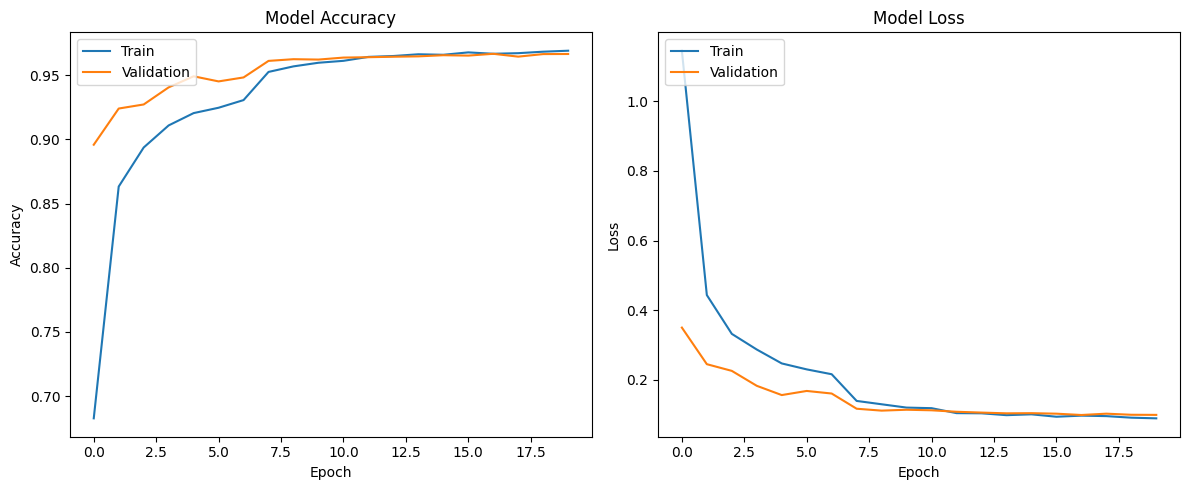

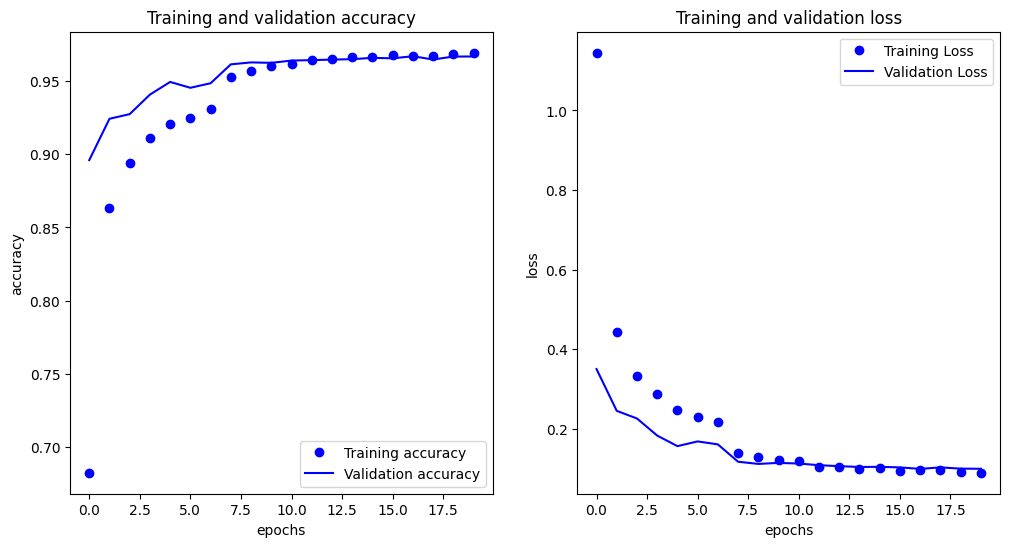

In [30]:
def plot_loss_acc(history):
    '''Plots the training and validation loss and accuracy from a history object'''
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(len(acc))

    fig, ax = plt.subplots(1,2, figsize=(12, 6))
    ax[0].plot(epochs, acc, 'bo', label='Training accuracy')
    ax[0].plot(epochs, val_acc, 'b', label='Validation accuracy')
    ax[0].set_title('Training and validation accuracy')
    ax[0].set_xlabel('epochs')
    ax[0].set_ylabel('accuracy')
    ax[0].legend()

    ax[1].plot(epochs, loss, 'bo', label='Training Loss')
    ax[1].plot(epochs, val_loss, 'b', label='Validation Loss')
    ax[1].set_title('Training and validation loss')
    ax[1].set_xlabel('epochs')
    ax[1].set_ylabel('loss')
    ax[1].legend()

    plt.show()

plot_loss_acc(history)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf

# Load model and get predictions
model = tf.keras.models.load_model("models/best_model.keras")

y_true = []
y_pred = []

for images, labels in test_dataset.take(100):
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)


In [ ]:

print(classification_report(y_true, y_pred, target_names=class_names))


                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      0.98      0.98        49
                                 Apple___Black_rot       1.00      1.00      1.00        54
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        18
                                   Apple___healthy       0.99      0.97      0.98       115
                               Blueberry___healthy       1.00      0.98      0.99       113
          Cherry_(including_sour)___Powdery_mildew       1.00      0.97      0.99        68
                 Cherry_(including_sour)___healthy       1.00      0.96      0.98        57
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.90      0.86      0.88        44
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00        94
               Corn_(maize)___Northern_Leaf_Blight       0.89      0.94      0.

FileNotFoundError: [Errno 2] No such file or directory: 'plots/confusion_matrix.png'

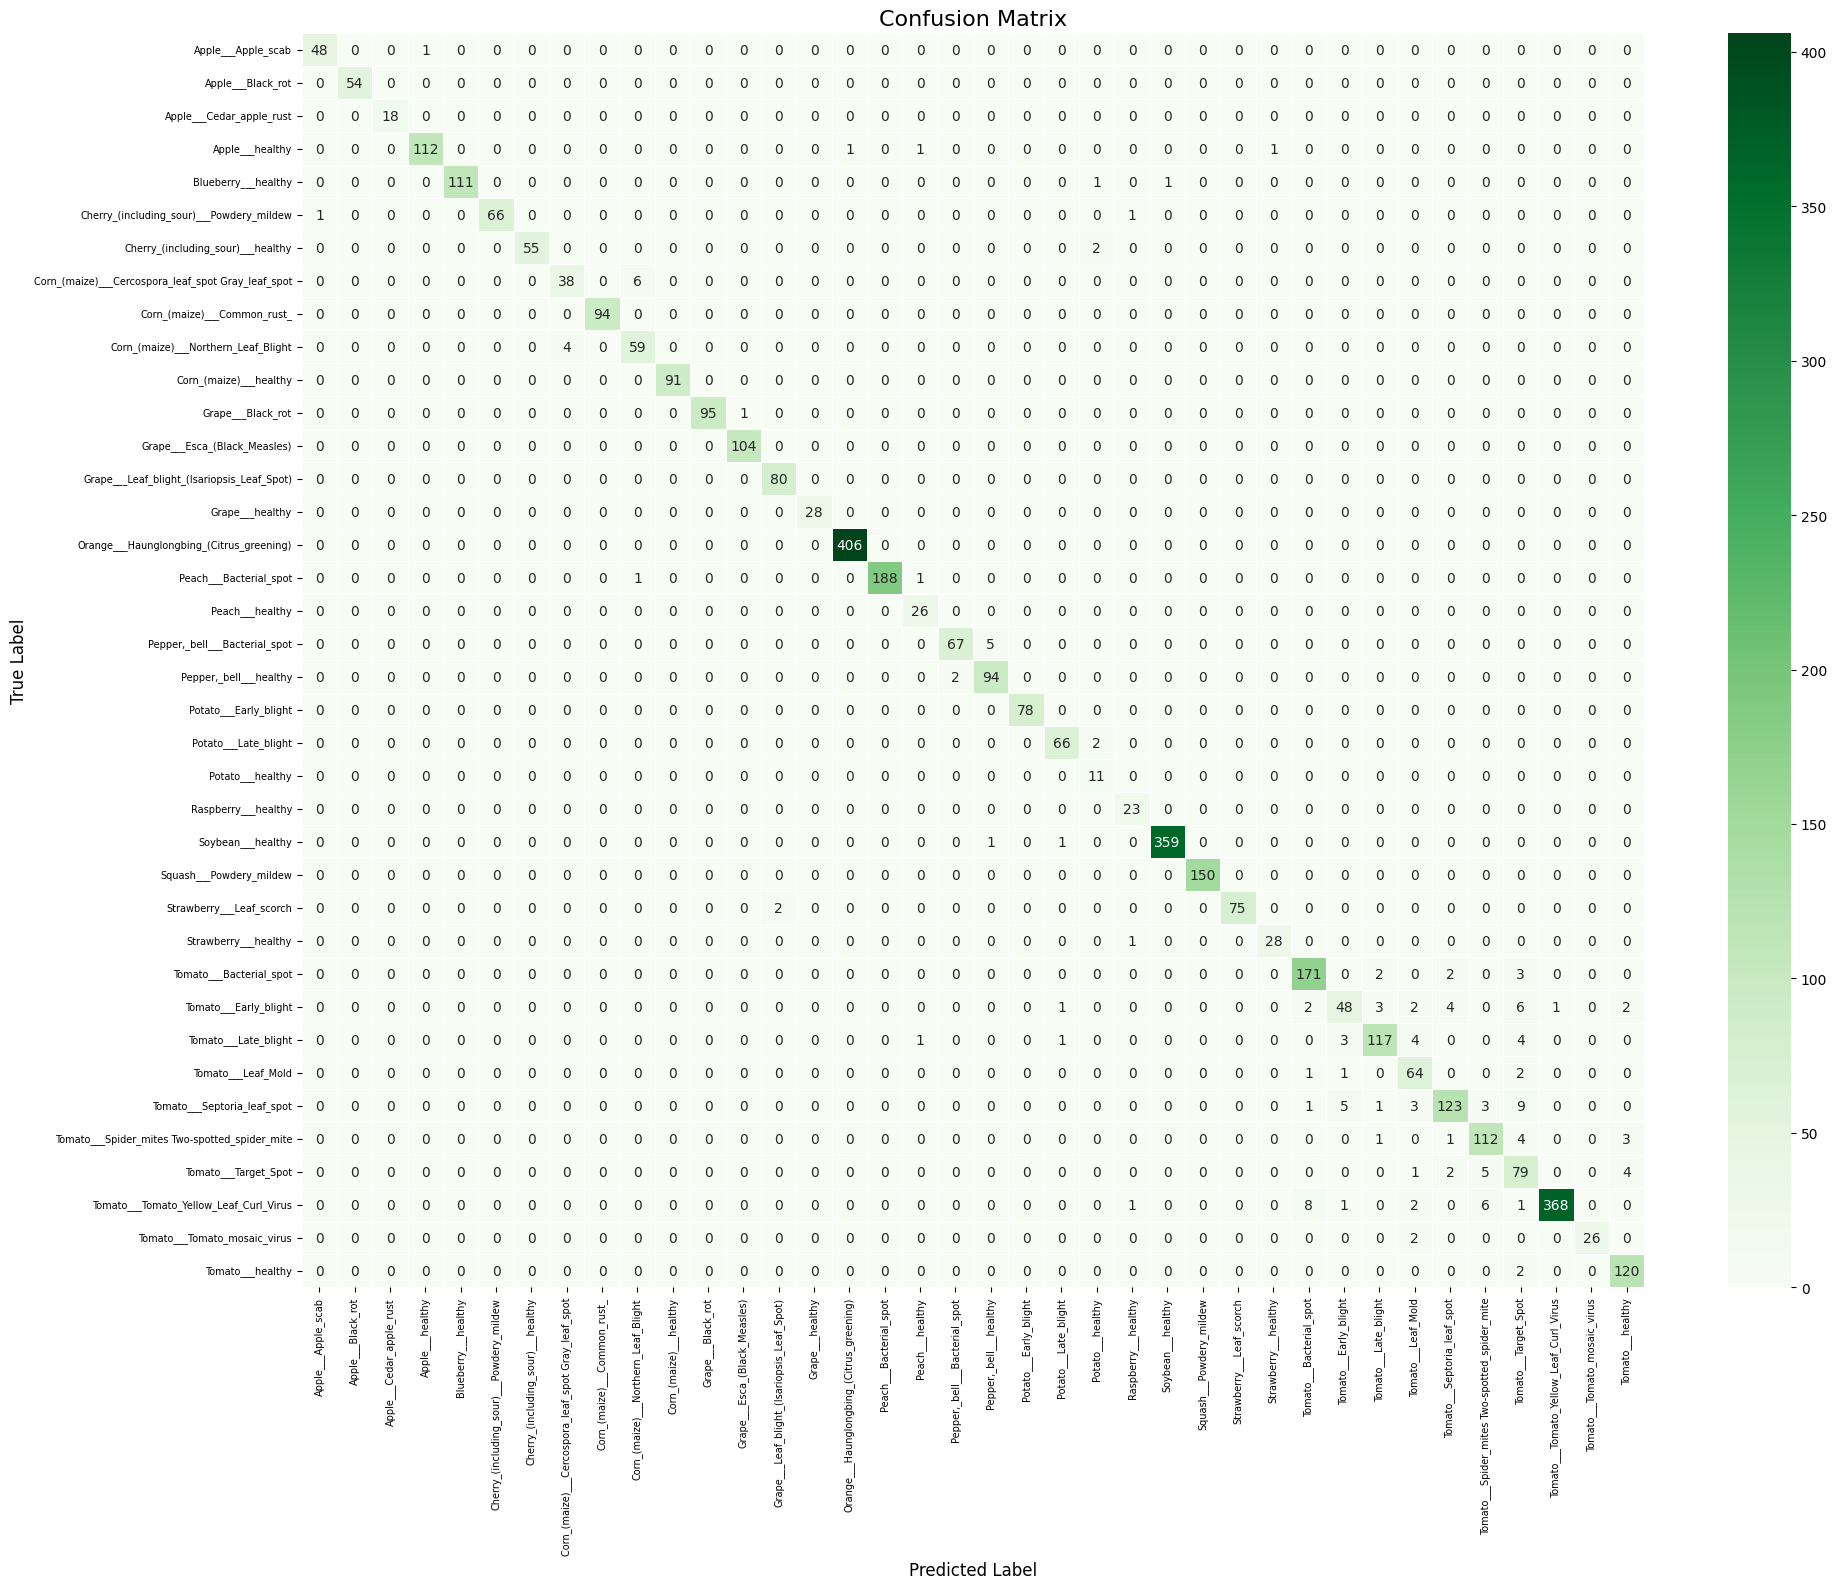

In [ ]:

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(20, 16))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5
)
plt.title("Confusion Matrix", fontsize=16)
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig("plots/confusion_matrix.png", dpi=150)
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'plots/per_class_accuracy.png'

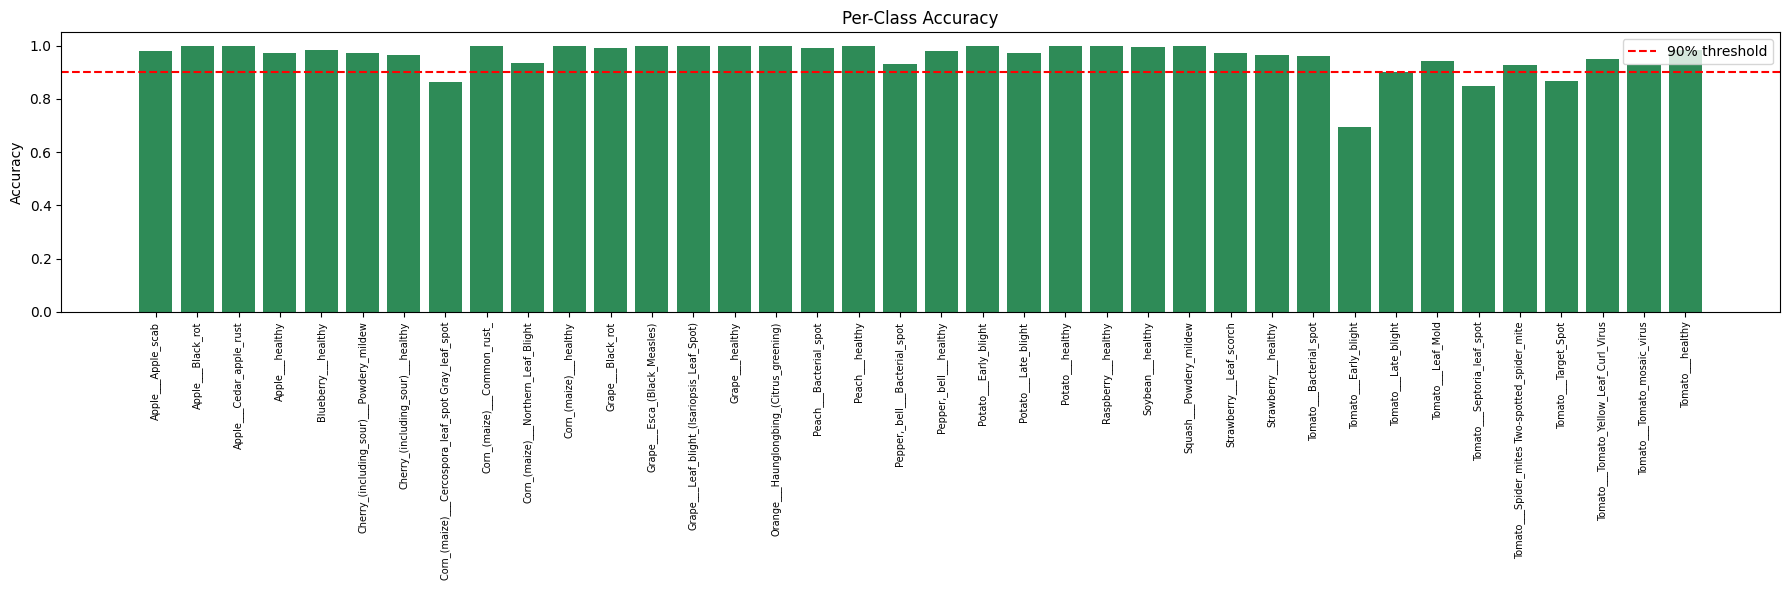

In [ ]:

per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(18, 6))
bars = plt.bar(class_names, per_class_acc, color="seagreen")
plt.xticks(rotation=90, fontsize=7)
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy")
plt.axhline(y=0.90, color='red', linestyle='--', label='90% threshold')
plt.legend()
plt.tight_layout()
plt.savefig("plots/per_class_accuracy.png", dpi=150)
plt.show()



Top 5 Worst Performing Classes:
  Tomato___Early_blight: 69.6%
  Tomato___Septoria_leaf_spot: 84.8%
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 86.4%
  Tomato___Target_Spot: 86.8%
  Tomato___Late_blight: 90.0%
